In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

C:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [151]:
df = pd.read_csv(r'../pre-calculated_data/bgc_region_len_gtdb.tsv',sep='\t',header=None,names=['GBK','type','category','start','end','length','mag','gtdb','domain','phylum','class','order','family','genus','species'])
cluster = pd.read_csv(r'../pre-calculated_data/mix_clustering_c0.3.tsv',sep='\t')
bgc_cluster= df.merge(cluster,on='GBK')

In [152]:
aci = bgc_cluster[bgc_cluster['phylum']=='p__Acidobacteriota']
aci

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species,Record,Record_Type,Record_Number,CC,Family
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,region,1,9,FAM_03771
5,cpsnj10_SemiBin_56.fa_contig_63352_polypolish....,NRPS-like.RRE-containing,NRPS.RiPP,40079,92751,52673,cpsnj10_SemiBin_56,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__2-12-FULL-66-21,g__JACCXG01,s__,cpsnj10_SemiBin_56.fa_contig_63352_polypolish....,region,1,21,FAM_00002
8,sample21_SemiBin_1792.fa_contig_21797_polypoli...,PKS-like.hserlactone,PKS.other,116076,157377,41302,sample21_SemiBin_1792,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__2-12-FULL-66-21,g__JACCXG01,s__,sample21_SemiBin_1792.fa_contig_21797_polypoli...,region,1,41,FAM_03775
18,sample26_SemiBin_4.fa_contig_10788_polypolish....,NRPS-like,NRPS,1351433,1393973,42541,sample26_SemiBin_4,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__2-12-FULL-66-21,g__JACCXG01,s__,sample26_SemiBin_4.fa_contig_10788_polypolish....,region,2,94,FAM_00064
19,sample18_SemiBin_245.fa_contig_75220_polypolis...,terpene,terpene,68965,89672,20708,sample18_SemiBin_245,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASRJG01,g__DASRJG01,s__,sample18_SemiBin_245.fa_contig_75220_polypolis...,region,2,98,FAM_03780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31618,sample1_SemiBin_188.fa_contig_180758_polypolis...,ranthipeptide,RiPP,21175,42623,21449,sample1_SemiBin_188,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__SCN-69-37,g__,s__,sample1_SemiBin_188.fa_contig_180758_polypolis...,region,1,147592,FAM_16295
31619,sample4_SemiBin_24.fa_contig_15480_polypolish....,RiPP-like,RiPP,665861,677054,11194,sample4_SemiBin_24,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__Pyrinomonadales,f__Pyrinomonadaceae,g__PSRF01,s__,sample4_SemiBin_24.fa_contig_15480_polypolish....,region,2,2129,FAM_00535
31621,cpsnj19_SemiBin_167.fa_contig_38754_polypolish...,RRE-containing,RiPP,70191,90403,20213,cpsnj19_SemiBin_167,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Fen-336,f__Fen-336,g__JAICEW01,s__,cpsnj19_SemiBin_167.fa_contig_38754_polypolish...,region,1,147604,FAM_16296
31622,sample7_SemiBin_145.fa_contig_75202_polypolish...,terpene,terpene,1,10361,10361,sample7_SemiBin_145,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__JACPPN01,g__,s__,sample7_SemiBin_145.fa_contig_75202_polypolish...,region,1,147608,FAM_16297


In [153]:
counts = aci[aci['genus'] != 'g__'].groupby(['genus', 'mag'])['Family'].nunique().reset_index()
counts 

,genus,mag,Family
0,g__12-FULL-67-14b,cpsnj02_SemiBin_81,5
1,g__12-FULL-67-14b,cpsnj03_SemiBin_10,2
2,g__12-FULL-67-14b,cpsnj03_SemiBin_110,3
3,g__12-FULL-67-14b,cpsnj03_SemiBin_78,3
4,g__12-FULL-67-14b,cpsnj04_SemiBin_112,4
...,...,...,...
1975,g__VFZN01,snj19_SemiBin_188,3
1976,g__VFZN01,snj20_SemiBin_183,2
1977,g__WHSN01,cpsnj09_SemiBin_45,1
1978,g__WHSN01,sample18_SemiBin_231,4


In [154]:
genus_avg = counts.groupby('genus')['Family'].mean().sort_values(ascending=False)
genus_avg

genus
g__UBA5704     18.571429
g__DATEKX01    11.000000
g__BOG-234     11.000000
g__DAISKN01     8.421053
g__JAHFTY01     8.000000
                 ...    
g__DASZRZ01     2.000000
g__DAHUXD01     1.772727
g__DATBFU01     1.000000
g__DATJFQ01     1.000000
g__JAENWF01     1.000000
Name: Family, Length: 125, dtype: float64

In [155]:
less_than_mean_count = (genus_avg < 4.22).sum()
total_genera = len(genus_avg)
percentage = (less_than_mean_count / total_genera) * 100
less_than_mean_count

69

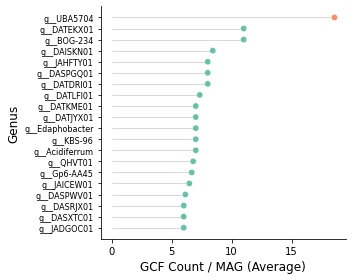

In [138]:
top_n = genus_avg.head(20).reset_index() 
top_n.columns = ['genus', 'avg_bgcs']

mean_val = 4.22

fig, ax = plt.subplots(figsize=(5, 4)) 

colors = ['#fc8d62' if x == 'g__UBA5704' else '#66c2a5' for x in top_n['genus']]

plt.hlines(y=top_n['genus'], xmin=0, xmax=top_n['avg_bgcs'], color='grey', alpha=0.3, linewidth=1)

plt.scatter(top_n['avg_bgcs'], top_n['genus'], color=colors, s=40, zorder=3, edgecolors='white', linewidths=0.5)

plt.xlabel('GCF Count / MAG (Average)', fontsize=12)
plt.ylabel('Genus', fontsize=12)

plt.yticks(fontsize=8) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.ylim(len(top_n), -1) 

plt.tight_layout()

In [156]:
UBA = bgc_cluster_o[bgc_cluster_o['genus']=='g__UBA5704']
UBA

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species,Record,Record_Type,Record_Number,CC,Family
113,snj02_SemiBin_33.fa_contig_1523_polypolish.reg...,NRPS.NRPS-like.T1PKS,NRPS.PKS,1,75458,75458,snj02_SemiBin_33,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj02_SemiBin_33.fa_contig_1523_polypolish.reg...,region,1,522,FAM_03815
254,snj02_SemiBin_33.fa_contig_63015_polypolish.re...,RRE-containing,RiPP,156925,177191,20267,snj02_SemiBin_33,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj02_SemiBin_33.fa_contig_63015_polypolish.re...,region,2,1262,FAM_03877
481,sample2_SemiBin_35.fa_contig_87020_polypolish....,RiPP-like,RiPP,21270,33447,12178,sample2_SemiBin_35,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,sample2_SemiBin_35.fa_contig_87020_polypolish....,region,1,2293,FAM_03964
517,snj02_SemiBin_33.fa_contig_47980_polypolish.re...,NRPS.T1PKS,NRPS.PKS,76042,316787,240746,snj02_SemiBin_33,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj02_SemiBin_33.fa_contig_47980_polypolish.re...,region,1,2445,FAM_03973
708,sample17_SemiBin_20.fa_contig_56357.region002,lanthipeptide-class-v.terpene,RiPP.terpene,184521,241397,56877,sample17_SemiBin_20,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,sample17_SemiBin_20.fa_contig_56357.region002....,region,2,3411,FAM_00714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30101,snj01_SemiBin_53.fa_contig_6850_polypolish.reg...,NRPS-like.lanthipeptide-class-iv,NRPS.RiPP,141215,184046,42832,snj01_SemiBin_53,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj01_SemiBin_53.fa_contig_6850_polypolish.reg...,region,2,140496,FAM_15675
30306,snj08_SemiBin_95.fa_contig_78313_polypolish.re...,NRPS,NRPS,1,26632,26632,snj08_SemiBin_95,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj08_SemiBin_95.fa_contig_78313_polypolish.re...,region,1,141457,FAM_15755
30852,snj08_SemiBin_95.fa_contig_23756_polypolish.re...,NRPS,NRPS,168482,204249,35768,snj08_SemiBin_95,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj08_SemiBin_95.fa_contig_23756_polypolish.re...,region,1,143991,FAM_15983
31059,snj08_SemiBin_95.fa_contig_8269_polypolish.reg...,indole.ladderane,other,42247,96413,54167,snj08_SemiBin_95,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj08_SemiBin_95.fa_contig_8269_polypolish.reg...,region,1,145033,FAM_16064


In [157]:
counts = UBA.groupby(['category'])['Family'].nunique().reset_index()
counts 

,category,Family
0,NRPS,39
1,NRPS.PKS,31
2,NRPS.PKS.RiPP,2
3,NRPS.PKS.other,1
4,NRPS.RiPP,3
5,NRPS.RiPP.terpene,1
6,PKS,11
7,RiPP,24
8,RiPP.terpene,3
9,other,11


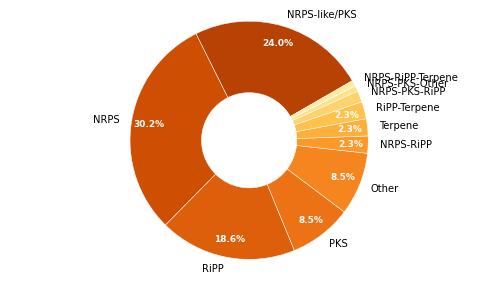

In [132]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['NRPS/PKS','NRPS', 'RiPP', 'PKS', 'Other', 'NRPS/RiPP', 
          'Terpene', 'RiPP/Terpene', 'NRPS/PKS/RiPP', 'NRPS/PKS/Other', 'NRPS/RiPP/Terpene']
sizes = [31,39, 24, 11, 11, 3, 3, 3, 2, 1, 1]


cmap = plt.get_cmap("YlOrBr")
colors = cmap(np.linspace(0.8, 0.2, len(sizes)))

fig, ax = plt.subplots(figsize=(7, 4))

wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct=lambda p: '{:.1f}%'.format(p) if p > 2 else '',
    startangle=30,
    pctdistance=0.85,    
    labeldistance=1.1,   
    wedgeprops={'width': 0.6, 'edgecolor': 'white', 'linewidth': 0.5}, 
    textprops={'fontsize': 10}
)

plt.setp(autotexts, size=9, weight="bold", color="white") 
plt.setp(texts, size=10) 

plt.axis('equal')  
plt.tight_layout()

In [158]:
counts = UBA.groupby(['mag'])['Family'].nunique().reset_index()
counts 

,mag,Family
0,sample17_SemiBin_20,13
1,sample18_SemiBin_189,7
2,sample2_SemiBin_35,12
3,snj01_SemiBin_53,38
4,snj02_SemiBin_33,26
5,snj08_SemiBin_95,21
6,snj09_SemiBin_114,13


In [159]:
counts = bgc_cluster.groupby(['phylum', 'mag'])['Family'].nunique().reset_index()
counts 

,phylum,mag,Family
0,p__ARS69,cpsnj11_SemiBin_122,2
1,p__ARS69,cpsnj14_SemiBin_7,3
2,p__ARS69,sample13_SemiBin_37,3
3,p__ARS69,sample13_SemiBin_38,3
4,p__ARS69,sample15_SemiBin_213,2
...,...,...,...
7453,p__Zhuqueibacterota,sample19_SemiBin_143,3
7454,p__Zhuqueibacterota,sample25_SemiBin_37,1
7455,p__Zhuqueibacterota,sample7_SemiBin_63,2
7456,p__Zixibacteria,sample19_SemiBin_217,1


In [160]:
phylum_avg = counts.groupby('phylum')['Family'].mean().sort_values(ascending=False)
top_phylum = phylum_avg.head(10).index.tolist()

top_data = counts[counts['phylum'].isin(top_phylum)]
top_data['phylum'] = pd.Categorical(top_data['phylum'], categories=top_phylum, ordered=True)
top_data

<ipython-input-160-48eff4936240>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_data['phylum'] = pd.Categorical(top_data['phylum'], categories=top_phylum, ordered=True)


,phylum,mag,Family
21,p__Acidobacteriota,cpsnj01_SemiBin_10,5
22,p__Acidobacteriota,cpsnj01_SemiBin_123,3
23,p__Acidobacteriota,cpsnj01_SemiBin_124,5
24,p__Acidobacteriota,cpsnj01_SemiBin_127,1
25,p__Acidobacteriota,cpsnj01_SemiBin_14,7
...,...,...,...
7447,p__Verrucomicrobiota,snj19_SemiBin_63,3
7448,p__Verrucomicrobiota,snj19_SemiBin_76,8
7449,p__Verrucomicrobiota,snj20_SemiBin_20,3
7450,p__Verrucomicrobiota,snj20_SemiBin_49,6


<ipython-input-97-b53fad41efef>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(data=top_data, x="phylum", y="Family",palette="Blues",linewidth=1.5)


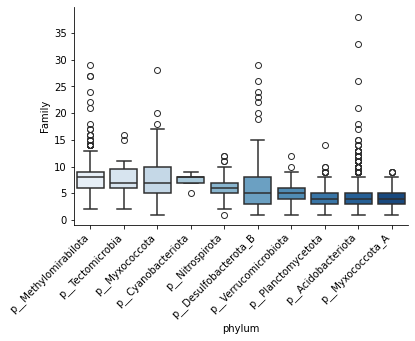

In [97]:
fig, ax = plt.subplots(figsize=(6, 4))
ax=sns.boxplot(data=top_data, x="phylum", y="Family",palette="Blues",linewidth=1.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(rotation=45, ha='right')

In [161]:
counts ['Family'].mean()

4.22177527487262

In [99]:
counts ['Family'].std()

2.976578900668701

In [107]:
phylum_gcf_summary = counts.groupby('phylum')['Family'].agg(['mean', 'std']).reset_index()
phylum_gcf_summary = phylum_gcf_summary.sort_values(by='mean', ascending=False)
phylum_gcf_summary

,phylum,mean,std
25,p__Methylomirabilota,8.199430,3.700208
34,p__Tectomicrobia,7.800000,3.876670
26,p__Myxococcota,7.664706,4.159461
10,p__Cyanobacteriota,7.400000,1.516575
28,p__Nitrospirota,6.141791,2.163098
13,p__Desulfobacterota_B,5.993127,4.151438
37,p__Verrucomicrobiota,4.894410,1.979907
31,p__Planctomycetota,4.310526,2.219060
1,p__Acidobacteriota,4.245947,2.487868
27,p__Myxococcota_A,4.111111,2.068732
